## Using saved data to make real time retreiver

In [ ]:
from Data.summaries import *

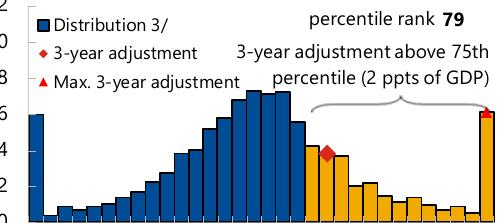

In [19]:
import base64
from IPython.display import Image, display

def display_base64_image(base64_code):
    # Decode the base64 string to binary
    image_data = base64.b64decode(base64_code)
    # Display the image
    display(Image(data=image_data))

display_base64_image(images[89])

In [2]:
import json
from unstructured.staging.base import dict_to_elements

# Load JSON
with open("chunks.json", "r", encoding="utf-8") as f:
    chunks_dict = json.load(f)

# Convert back to elements
chunks = dict_to_elements(chunks_dict)


In [3]:
# We get 2 types of elements from the partition_pdf function
set([str(type(el)) for el in chunks])

{"<class 'unstructured.documents.elements.CompositeElement'>"}

In [4]:
# separate tables from texts
tables = []
texts = []
# images = []

for chunk in chunks:
    if "Table" in str(type(chunk)):
        tables.append(chunk)

    if "CompositeElement" in str(type((chunk))):
        texts.append(chunk)

# Get the images from the CompositeElement objects
def get_images_base64(chunks):
    images_b64 = []
    for chunk in chunks:
        if "CompositeElement" in str(type(chunk)):
            chunk_els = chunk.metadata.orig_elements
            for el in chunk_els:
                if "Image" in str(type(el)):
                    images_b64.append(el.metadata.image_base64)
    return images_b64

images = get_images_base64(chunks)

from unstructured.documents.elements import Table, CompositeElement

def get_tables(chunks):
    tables = []
    for chunk in chunks:
        if isinstance(chunk, CompositeElement):
            for el in chunk.metadata.orig_elements:
                if isinstance(el, Table):
                    tables.append(el)
    return tables
tables = get_tables(chunks)

In [7]:
print(len(texts))
print(len(tables))
print(len(images))

55
27
100


## Vector Stores

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [ ]:
import uuid
from langchain_chroma import Chroma
from langchain_core.stores import InMemoryStore  
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_classic.retrievers.multi_vector import MultiVectorRetriever

# The vectorstore to use to index the child chunks
# vectorstore = Chroma(collection_name="multi_modal_rag", embedding_function=OpenAIEmbeddings())

# The storage layer for the parent documents
store = InMemoryStore()
id_key = "doc_id"

# # The retriever (empty to start)
# retriever = MultiVectorRetriever(
#     vectorstore=vectorstore,
#     docstore=store,
#     id_key=id_key,
#     persist_directory=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\chroma_IAI101_db"    
# )


c:\ProgramData\anaconda3\envs\FreeGenAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import faiss
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings()

embedding_dim = len(embeddings.embed_query("hello world"))
index = faiss.IndexFlatL2(embedding_dim)

vectorstore = FAISS(
    embedding_function=OpenAIEmbeddings(),
    index=index,
    docstore=InMemoryDocstore(),
    index_to_docstore_id={},
)

# The retriever (empty to start)
retriever2 = MultiVectorRetriever(
    vectorstore=vectorstore,
    docstore=store,
    id_key=id_key,
    # persist_directory=r"C:\Users\dewan\Coding\MLOps\IAI_Solutions\FAISS_IAI_VS101"    
)


In [12]:
# Add texts
doc_ids = [str(uuid.uuid4()) for _ in texts]
summary_texts = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]}) for i, summary in enumerate(text_summaries)
]
retriever2.vectorstore.add_documents(summary_texts)
retriever2.docstore.mset(list(zip(doc_ids, texts)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


# Add tables
table_ids = [str(uuid.uuid4()) for _ in tables]
summary_tables = [
    Document(page_content=summary, metadata={id_key: table_ids[i]}) for i, summary in enumerate(table_summaries)
]
retriever2.vectorstore.add_documents(summary_tables)
retriever2.docstore.mset(list(zip(table_ids, tables)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


# Add image summaries
img_ids = [str(uuid.uuid4()) for _ in images]
summary_img = [
    Document(page_content=summary, metadata={id_key: img_ids[i]}) for i, summary in enumerate(image_summaries)
]
retriever2.vectorstore.add_documents(summary_img)
retriever2.docstore.mset(list(zip(img_ids, images)))
print("Documents added:", retriever2.vectorstore.index.ntotal)


Documents added: 55
Documents added: 82
Documents added: 182


In [13]:
# Retrieve
docs = retriever2.invoke(
    "Qatar’s Diversification Progress and Challenges"
)

In [14]:
docs

In [16]:
for doc in docs:
    print(str(doc)+"\n"+ "-"*80)

30. Boosting Qatar’s economic complexity calls for (Text Figures 18 and 19):

e Fostering innovation. Qatar's patent applications rose rapidly over the last decade, more so than in its GCC peers. To promote innovation and support start-ups, a venture capital program ("Fund of Funds”) is being established by the QIA. NDS3 aims to increase Qatar's R&D funding from the current 0.7 percent of GDP to 1.5 percent, with the majority from the private sector. More attention is needed to enhance Qatar’s R&D spending efficiency and quality. Further improvement in intellectual property rights protection (e.g., in patent and trademark protection) is also key.

13 See Annex IX. “Promoting Gender Equality: Enhancing Women’s Workforce in Qatar” in the 2023 Staff Report for Qatar.

22 INTERNATIONAL MONETARY FUND

QATAR

e Promoting trade diversification. Progress in Qatar's export diversification is limited, mainly in services export (transportation and tourism). For a country with a small domestic mar

## RAG Pipeline

In [17]:
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from base64 import b64decode
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def parse_docs(docs):
    """Split base64-encoded images and texts"""
    b64 = []
    text = []
    for doc in docs:
        try:
            b64decode(doc)
            b64.append(doc)
        except Exception as e:
            text.append(doc)
    return {"images": b64, "texts": text}


def build_prompt(kwargs):

    docs_by_type = kwargs["context"]
    user_question = kwargs["question"]

    context_text = ""
    if len(docs_by_type["texts"]) > 0:
        for text_element in docs_by_type["texts"]:
            context_text += text_element.text

    # construct prompt with context (including images)
    prompt_template = f"""
    Answer the question based only on the following context, which can include text, tables, and the below image.
    Context: {context_text}
    Question: {user_question}
    """

    prompt_content = [{"type": "text", "text": prompt_template}]

    if len(docs_by_type["images"]) > 0:
        for image in docs_by_type["images"]:
            prompt_content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:image/jpeg;base64,{image}"},
                }
            )

    return ChatPromptTemplate.from_messages(
        [
            HumanMessage(content=prompt_content),
        ]
    )


chain = (
    {
        "context": retriever2 | RunnableLambda(parse_docs),
        "question": RunnablePassthrough(),
    }
    | RunnableLambda(build_prompt)
    | ChatOpenAI(model="gpt-4o-mini")
    | StrOutputParser()
)

chain_with_sources = {
    "context": retriever2 | RunnableLambda(parse_docs),
    "question": RunnablePassthrough(),
} | RunnablePassthrough().assign(
    response=(
        RunnableLambda(build_prompt)
        | ChatOpenAI(model="gpt-4o-mini")
        | StrOutputParser()
    )
)

Response: Real non-hydro GDP growth in Qatar experienced fluctuations from 2016 to 2023. It showed a positive trend in 2016 and peaked in 2018, reflecting strong growth in non-hydrocarbon sectors. However, it faced declines in subsequent years, particularly in 2020, aligning with a downturn in overall GDP growth. By 2022, the growth remained modest, indicating weakness in non-hydrocarbon activities, and further slowed in 2023, although specific values are not provided in the context.


Context:
Figure 5. Qatar: Credit and Financial Sector Developments

Real private sector credit growth picked up since late 2023...

..While credit to the public sector remains the largest share of bank assets.

Bank Credit to Private Sector

(Percent, year on year)

Stock of Bank Domestic Credit by Borrower (Percent of total)

30 Real Nominal 20 10 12 #14 #16 #18 20 22 24

40 October 2024 e 30 e 2019 average 20 e 0 N ER efion x A) 2 £ ire] io) 2 iv) Real esta Consumption loans

Banks’ credit to non-hydro

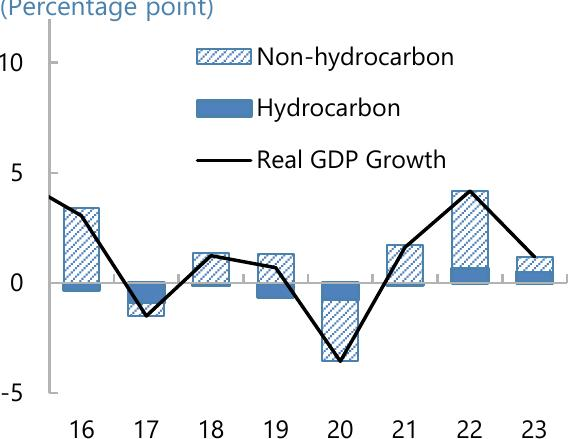

In [20]:
response = chain_with_sources.invoke(
    "What is Real Non-hydro GDP Growth?"
)

print("Response:", response['response'])

print("\n\nContext:")
for text in response['context']['texts']:
    print(text.text)
    print("Page number: ", text.metadata.page_number)
    print("\n" + "-"*50 + "\n")
for image in response['context']['images']:
    display_base64_image(image)